# **PREPARAÇÃO DE DADOS**

# Considerações iniciais



LOrem

## Tratamento de PARTICIPANTES_2024

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [2]:
ano = 2023

In [3]:
arquivo_microdados = Path('../data/data_raw') / f'MICRODADOS_ENEM_{ano}.csv'
df_microdados = pd.read_csv(arquivo_microdados, sep=';', encoding='latin-1')

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df_microdados.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,210059085136,2023,14,M,2,1,1,1,17,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5300108,Brasília,53,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,F,E,D,5,F,C,C,D,C,D,C,B,B,D,C,C,B,B,A,B,B,A,A,B
1,210059527735,2023,12,M,2,1,0,1,16,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5300108,Brasília,53,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,E,E,B,3,H,A,B,C,C,A,B,B,B,A,B,A,B,B,A,A,C,A,D,B
2,210061103945,2023,6,F,1,1,1,1,0,1,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4305108,Caxias do Sul,43,RS,1,1,1,1,1221.0,1193.0,1204.0,1211.0,502.0,498.9,475.6,363.2,DBEBDCECCBCEBBBBDBABDDBBAABCBACDBACECCBAADEBB,ABDEADAADCDABDCADAEABCDDCBAADCCBEBCEBEBDBEAED,ACEBDCABAACAEBAECEBBBAAECBBDEADCAECCCEDDABEED,CEAEACCCDABCDAACEDDBAAEBABDDEEBDAECABDBCBCADE,1,DBEABDABDCACDBECDDDBCAAABBACCCADEBECCCEDAEEED,ACEEABAADCDAADEABCDABCDCABCBDADEBAECABADBCDAE,DBABBAEBAAAACDACDEDAACADBADBCCEACCCEAAECBBEBCA...,BCCDEEABCBEDCEABBEBDABDDADDADECAADDCCBEBEABCC,1.0,140.0,200.0,100.0,120.0,140.0,700.0,H,E,C,F,5,C,A,B,D,B,A,B,A,B,A,B,A,A,B,A,A,A,A,A,B
3,210060214087,2023,2,F,1,3,1,2,0,2,1.0,0,2304400.0,Fortaleza,23.0,CE,2.0,1.0,1.0,2304400,Fortaleza,23,CE,1,1,1,1,1224.0,1192.0,1202.0,1214.0,459.0,508.5,507.2,466.7,DEEBEACCCEBDDBDCCCAEEDCBAAADBCBEEEDCDAAECBEEC,DDAAEEBCCDEADBCDDCBAECABEBDEBDABECECEDCDDAEED,ADBDADAEEEACAABBACADCAEBBAAEBBCDEBBDDADDCADAA,EECBAEDEEDDDBBAADEECDBBBECEAACEAEECDBEDDBCDCB,0,CDDDABBABDBEABDECCEEEDCEDAEBABDCCAACCCADACDBE,DBAADEADCDCABABCDDEBAEABAECABAACECDAECBDAABCD,BBBDAABAEACCEEEDEACBCACAACAACAAAECBBEDBCCADBDE...,EBDADDAEBEACBEDCECCBEABCADEBCCBCCDEBDDAABBADD,1.0,140.0,200.0,160.0,180.0,200.0,880.0,D,D,B,B,5,C,A,B,B,A,A,B,A,A,A,A,A,A,B,A,A,D,A,A,B
4,210059980948,2023,3,F,1,3,1,2,0,2,1.0,0,2311306.0,Quixadá,23.0,CE,2.0,1.0,1.0,2311306,Quixadá,23,CE,1,1,1,1,1222.0,1191.0,1201.0,1212.0,402.5,379.2,446.9,338.3,AECCEAACDEABEEECDBAEEAAADDEABCBCEBACEEDCBEABD,CADEBCEDDEBCBAEBADDCECACADBDEBABDBDBEEDBBEADC,AABBACBCAEDABDADEDAACCAEEEECAACDCADBAEACDEAAE,CDBABEDCEEBBBDECDEBACCAABDEDCBECDECABBDBDEECC,0,CAAADCCCCDDDABDCACDBEEEDCEDAEECCDBEABDBABBAEB,CDAEECABAACEAADECBDAABCDCABADCDEABAABCDDEBADB,BBDABAAEBADACEEDCCDBADBDEDCCEBCACEACAACAACACBB...,DCECACCBDECBEEABEABDDAADDABBBCCBCCDDAEBDADEEB,1.0,120.0,120.0,120.0,120.0,80.0,560.0,B,B,A,A,4,B,A,B,A,A,A,B,A,A,A,A,A,A,B,A,A,B,A,A,A


In [5]:
df_participantes = df_microdados[["NO_MUNICIPIO_PROVA", "CO_MUNICIPIO_PROVA", "IN_TREINEIRO", "SG_UF_PROVA", "Q006"]]
df_participantes = df_participantes.rename(columns={'NO_MUNICIPIO_PROVA': 'MUNICIPIO', 'CO_MUNICIPIO_PROVA': 'COD_MUNICIPIO'})
df_participantes.head()

,MUNICIPIO,COD_MUNICIPIO,IN_TREINEIRO,SG_UF_PROVA,Q006
0,Brasília,5300108,0,DF,F
1,Brasília,5300108,0,DF,H
2,Caxias do Sul,4305108,0,RS,C
3,Fortaleza,2304400,0,CE,C
4,Quixadá,2311306,0,CE,B


In [6]:
df_participantes_descarte = df_microdados[["NO_MUNICIPIO_ESC", "CO_MUNICIPIO_ESC", "IN_TREINEIRO", "SG_UF_PROVA", "Q006"]]
df_participantes_descarte = df_participantes_descarte.rename(columns={'NO_MUNICIPIO_ESCOLA': 'MUNICIPIO', 'CO_MUNICIPIO_ESCOLA': 'COD_MUNICIPIO'})

df_participantes_descarte.isnull().mean()*100

NO_MUNICIPIO_ESC    75.635054
CO_MUNICIPIO_ESC    75.635054
IN_TREINEIRO         0.000000
SG_UF_PROVA          0.000000
Q006                 0.000000
dtype: float64

In [7]:
df_participantes.info()

<class 'pandas.DataFrame'>
RangeIndex: 3933955 entries, 0 to 3933954
Data columns (total 5 columns):
 #   Column         Dtype
---  ------         -----
 0   MUNICIPIO      str  
 1   COD_MUNICIPIO  int64
 2   IN_TREINEIRO   int64
 3   SG_UF_PROVA    str  
 4   Q006           str  
dtypes: int64(2), str(3)
memory usage: 150.1 MB


In [9]:
df_participantes.isnull().mean()*100

MUNICIPIO        0.0
COD_MUNICIPIO    0.0
IN_TREINEIRO     0.0
SG_UF_PROVA      0.0
Q006             0.0
dtype: float64

In [10]:
cor_renda_map_sm = {
    "A": 0.0,
    "B": 0.5,
    "C": 1.25,
    "D": 1.75,
    "E": 2.25,
    "F": 2.75,
    "G": 3.5,
    "H": 4.5,
    "I": 5.5,
    "J": 6.5,
    "K": 7.5,
    "L": 8.5,
    "M": 9.5,
    "N": 11.0,
    "O": 13.5,
    "P": 17.5,
    "Q": 20.0 
}
df_participantes['Q006'] = df_participantes['Q006'].map(cor_renda_map_sm)
df_participantes['Q006'] = df_participantes['Q006'].astype("float64")
df_participantes = df_participantes.rename(columns={'Q006': 'RENDA_FAMILIAR_SM'})

In [11]:
if 'RENDA_FAMILIAR_SM' in df_participantes.columns:
    if not np.issubdtype(df_participantes['RENDA_FAMILIAR_SM'].dropna().dtype, np.number):
        df_participantes['RENDA_FAMILIAR_SM'] = df_participantes['RENDA_FAMILIAR_SM'].map(cor_renda_map_sm)

    media_q006_por_uf = df_participantes.groupby('SG_UF_PROVA')['RENDA_FAMILIAR_SM'].transform('mean')
    df_participantes['RENDA_FAMILIAR_SM'] = df_participantes['RENDA_FAMILIAR_SM'].fillna(media_q006_por_uf)

    df_participantes['RENDA_FAMILIAR_SM'] = df_participantes['RENDA_FAMILIAR_SM'].fillna(df_participantes['RENDA_FAMILIAR_SM'].mean())

In [12]:
df_participantes.isnull().sum()*100

MUNICIPIO            0
COD_MUNICIPIO        0
IN_TREINEIRO         0
SG_UF_PROVA          0
RENDA_FAMILIAR_SM    0
dtype: int64

In [13]:
df_participantes.info()

<class 'pandas.DataFrame'>
RangeIndex: 3933955 entries, 0 to 3933954
Data columns (total 5 columns):
 #   Column             Dtype  
---  ------             -----  
 0   MUNICIPIO          str    
 1   COD_MUNICIPIO      int64  
 2   IN_TREINEIRO       int64  
 3   SG_UF_PROVA        str    
 4   RENDA_FAMILIAR_SM  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 150.1 MB


In [14]:
df_participantes = df_participantes[df_participantes['IN_TREINEIRO'] != 1]
df_participantes = df_participantes.drop(columns=['IN_TREINEIRO'])

In [15]:
df_participantes['MUNICIPIO'] = df_participantes['MUNICIPIO'].str.upper()

In [16]:
df_participantes.info()

<class 'pandas.DataFrame'>
Index: 3313888 entries, 0 to 3933954
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   MUNICIPIO          str    
 1   COD_MUNICIPIO      int64  
 2   SG_UF_PROVA        str    
 3   RENDA_FAMILIAR_SM  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 126.4 MB


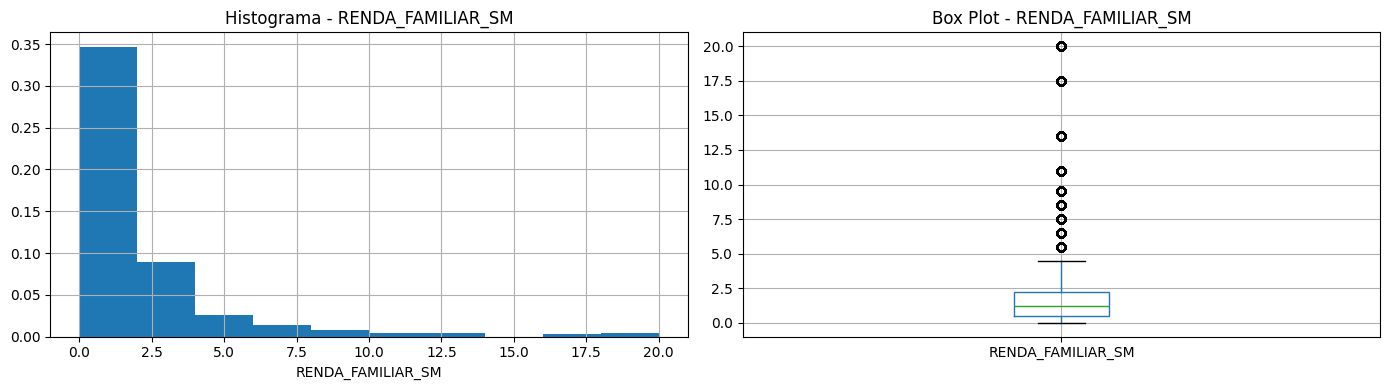

In [17]:
analise_cols = ['RENDA_FAMILIAR_SM']

for col in analise_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    df_participantes[col].hist(ax=ax1, density=True)
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)
    
    df_participantes.boxplot(column=col, ax=ax2)
    ax2.set_title(f'Box Plot - {col}')
    
    plt.tight_layout()
    plt.show()

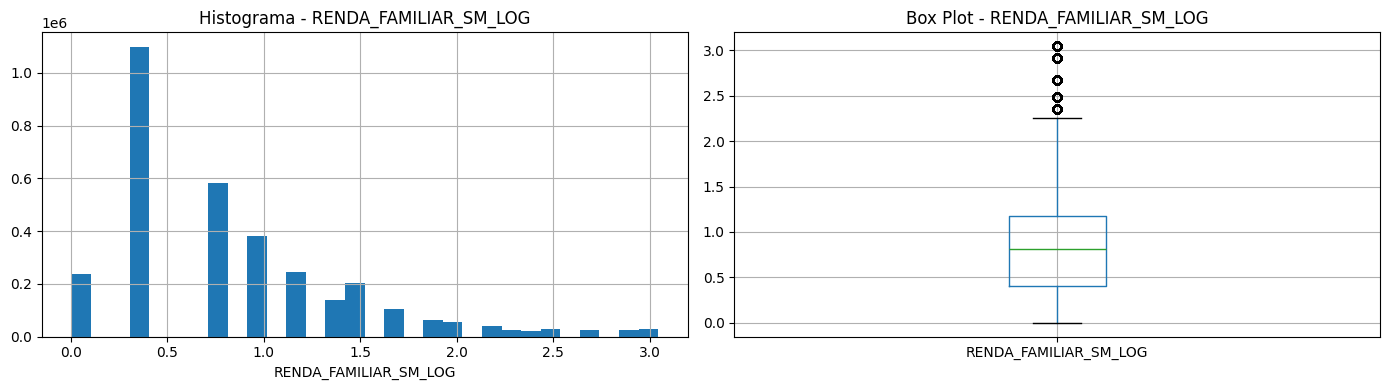

In [18]:
df_participantes['RENDA_FAMILIAR_SM_LOG'] = np.log1p(df_participantes['RENDA_FAMILIAR_SM'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

df_participantes['RENDA_FAMILIAR_SM_LOG'].hist(ax=ax1, bins=30)
ax1.set_title('Histograma - RENDA_FAMILIAR_SM_LOG')
ax1.set_xlabel('RENDA_FAMILIAR_SM_LOG')

df_participantes.boxplot(column='RENDA_FAMILIAR_SM_LOG', ax=ax2)
ax2.set_title('Box Plot - RENDA_FAMILIAR_SM_LOG')

plt.tight_layout()
plt.show()


In [19]:
df_tratamento_outlier = df_participantes.copy()

valores_q1 = [0.25, 0.2, 0.15, 0.1, 0.05]
valores_q3 = [0.75, 0.8, 0.85, 0.9, 0.95]

col = 'RENDA_FAMILIAR_SM_LOG'

for q1_val, q3_val in zip(valores_q1, valores_q3):
    df_col_filtrado = df_tratamento_outlier.copy()

    Q1 = df_tratamento_outlier[col].quantile(q1_val)
    Q3 = df_tratamento_outlier[col].quantile(q3_val)
    IQR = Q3 - Q1

    df_col_filtrado = df_col_filtrado[
        (df_col_filtrado[col] >= Q1 - 1.5 * IQR) &
        (df_col_filtrado[col] <= Q3 + 1.5 * IQR)
    ]

    proporcao_removida = (
        (df_tratamento_outlier.shape[0] - df_col_filtrado.shape[0])
        / df_tratamento_outlier.shape[0]
    ) * 100

    if proporcao_removida <= 5:
        print(f'Tratamento de outliers de renda | Q1={q1_val}, Q3={q3_val} {proporcao_removida:.2f}% removidos')
        df_tratamento_outlier = df_col_filtrado.copy()
        break
else:
    print(f'Nenhum corte adequado para {col} — mantendo dados originais\n')

df_participantes = df_tratamento_outlier.copy()
df_participantes = df_participantes.drop(columns=['RENDA_FAMILIAR_SM_LOG'])


Tratamento de outliers de renda | Q1=0.25, Q3=0.75 4.01% removidos


In [20]:
df_municipio = df_participantes.groupby('COD_MUNICIPIO').agg(
    MUNICIPIO=('MUNICIPIO', 'first'),
    RENDA_FAMILIAR_SM_MEDIA=('RENDA_FAMILIAR_SM', 'mean')
).reset_index()

In [21]:
df_municipio.head()

,COD_MUNICIPIO,MUNICIPIO,RENDA_FAMILIAR_SM_MEDIA
0,1100015,ALTA FLORESTA D'OESTE,1.611017
1,1100023,ARIQUEMES,1.776483
2,1100049,CACOAL,1.906845
3,1100056,CEREJEIRAS,1.916968
4,1100064,COLORADO DO OESTE,2.139803


## Tratamento Resultados

In [22]:
df_resultado = df_microdados[['SG_UF_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_MUNICIPIO_PROVA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO' ]]
df_resultado = df_resultado.rename(columns={'NO_MUNICIPIO_PROVA': 'MUNICIPIO', 'CO_MUNICIPIO_PROVA': 'COD_MUNICIPIO'})

In [23]:
df_resultado.head()

,SG_UF_PROVA,MUNICIPIO,COD_MUNICIPIO,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
0,DF,Brasília,5300108,0,0,0,0,NaN,NaN,NaN,NaN,NaN
1,DF,Brasília,5300108,0,0,0,0,NaN,NaN,NaN,NaN,NaN
2,RS,Caxias do Sul,4305108,1,1,1,1,502.0,498.9,475.6,363.2,700.0
3,CE,Fortaleza,2304400,1,1,1,1,459.0,508.5,507.2,466.7,880.0
4,CE,Quixadá,2311306,1,1,1,1,402.5,379.2,446.9,338.3,560.0


In [24]:
df_resultado.isnull().mean()*100

SG_UF_PROVA         0.000000
MUNICIPIO           0.000000
COD_MUNICIPIO       0.000000
TP_PRESENCA_CN      0.000000
TP_PRESENCA_CH      0.000000
TP_PRESENCA_LC      0.000000
TP_PRESENCA_MT      0.000000
NU_NOTA_CN         31.559283
NU_NOTA_CH         28.249230
NU_NOTA_LC         28.249230
NU_NOTA_MT         31.559283
NU_NOTA_REDACAO    28.249230
dtype: float64

In [25]:
df_resultado = df_resultado[df_resultado['TP_PRESENCA_CN'] == 1]
df_resultado = df_resultado[df_resultado['TP_PRESENCA_CH'] == 1]
df_resultado = df_resultado[df_resultado['TP_PRESENCA_LC'] == 1]
df_resultado = df_resultado[df_resultado['TP_PRESENCA_MT'] == 1]

df_resultado = df_resultado.drop(columns=['TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT'])

In [26]:
df_resultado.isnull().mean()*100

SG_UF_PROVA        0.0
MUNICIPIO          0.0
COD_MUNICIPIO      0.0
NU_NOTA_CN         0.0
NU_NOTA_CH         0.0
NU_NOTA_LC         0.0
NU_NOTA_MT         0.0
NU_NOTA_REDACAO    0.0
dtype: float64

In [27]:
df_resultado.head()

,SG_UF_PROVA,MUNICIPIO,COD_MUNICIPIO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
2,RS,Caxias do Sul,4305108,502.0,498.9,475.6,363.2,700.0
3,CE,Fortaleza,2304400,459.0,508.5,507.2,466.7,880.0
4,CE,Quixadá,2311306,402.5,379.2,446.9,338.3,560.0
9,SP,Batatais,3505906,564.7,630.3,610.4,680.2,600.0
10,RN,Natal,2408102,644.9,620.2,626.9,736.3,860.0


In [28]:
analise_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

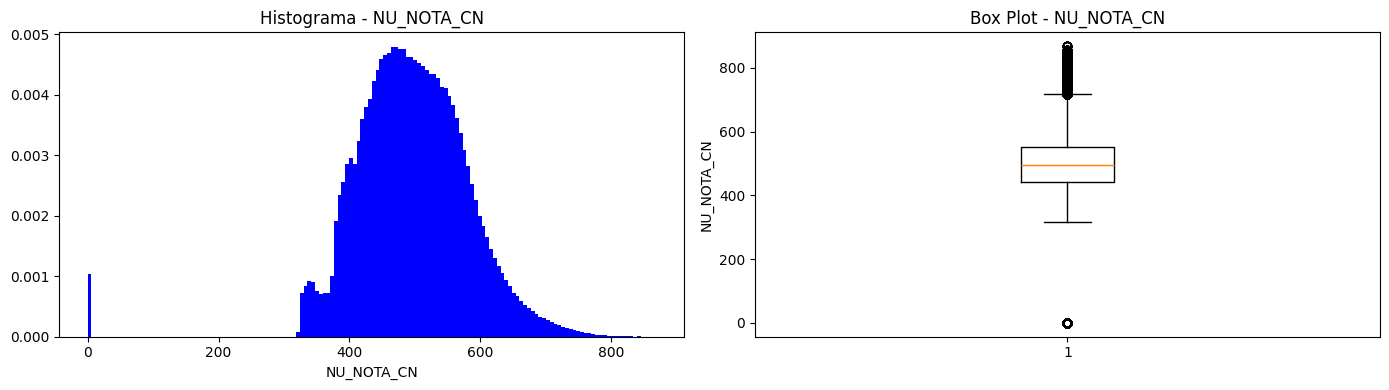

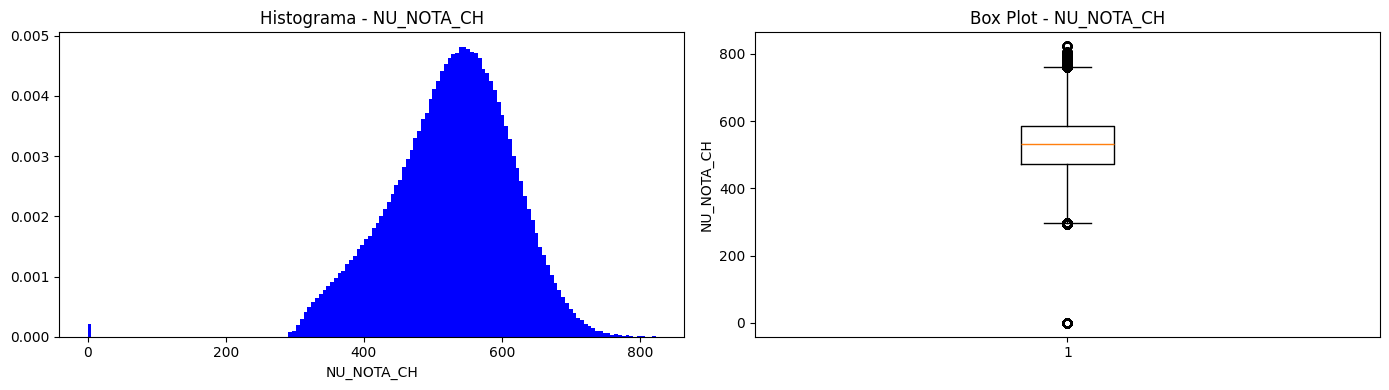

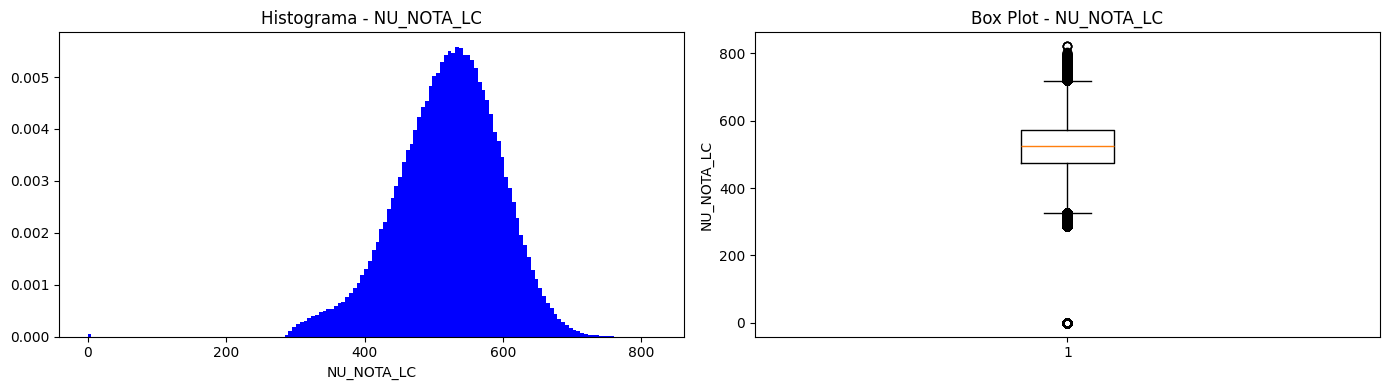

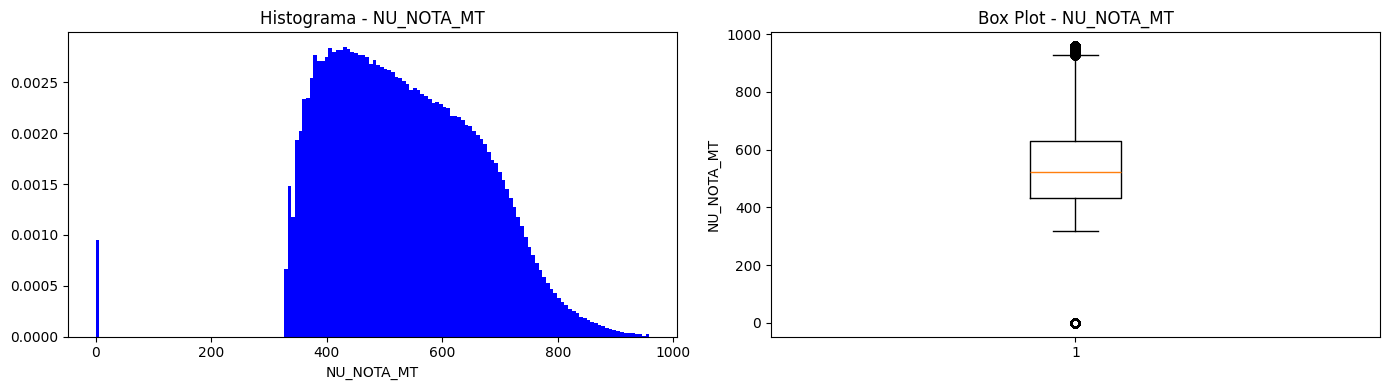

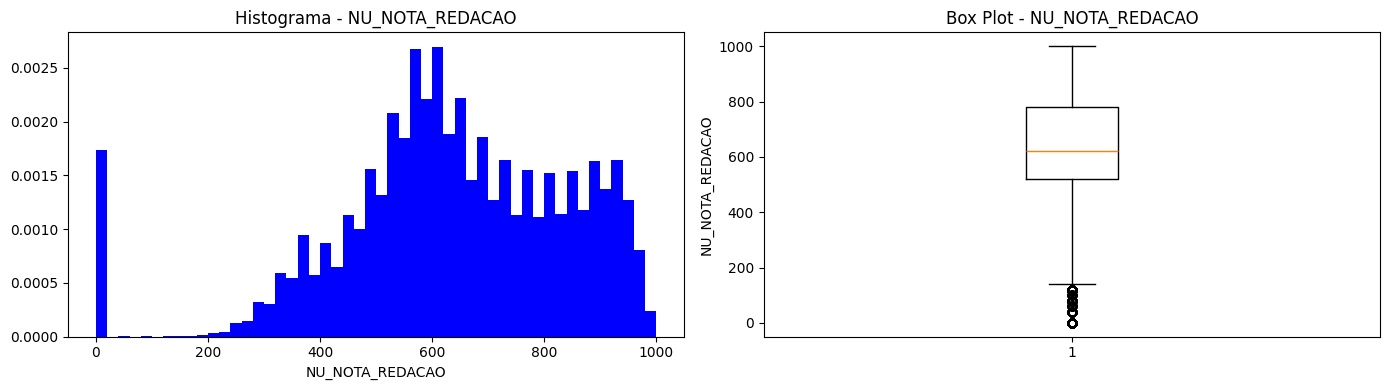

In [29]:
for col in analise_notas:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    if col == 'NU_NOTA_REDACAO':
        ax1.hist(df_resultado[col].dropna(), bins=50, density=True, color='blue')
    else:
        ax1.hist(df_resultado[col].dropna(), bins=150, density=True, color='blue')
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)

    ax2.boxplot(df_resultado[col].dropna(), vert=True)
    ax2.set_title(f'Box Plot - {col}')
    ax2.set_ylabel(col)

    plt.tight_layout()
    plt.show()


In [30]:
df_tratamento_outlier = df_resultado.copy()

valores_q1 = [0.25, 0.2, 0.15, 0.1, 0.05]
valores_q3 = [0.75, 0.8, 0.85, 0.9, 0.95]

n_original = df_resultado.shape[0]

for q1_val, q3_val in zip(valores_q1, valores_q3):
    
    df_temp = df_resultado.copy()
    
    for col in analise_notas:
        Q1 = df_resultado[col].quantile(q1_val)
        Q3 = df_resultado[col].quantile(q3_val)
        IQR = Q3 - Q1
        
        df_temp = df_temp[
            (df_temp[col] >= Q1 - 1.5 * IQR) & 
            (df_temp[col] <= Q3 + 1.5 * IQR)
        ]
    
    proporcao_total = (
        (n_original - df_temp.shape[0]) / n_original
    ) * 100
    

    if proporcao_total <= 5:
        print(f'Tratamento de outliers de notas | Q1={q1_val}, Q3={q3_val} {proporcao_total:.2f}% removidos')
        df_tratamento_outlier = df_temp.copy()
        break
else:
    print('Nenhum corte global válido — mantendo dados')

print(f'\nTotal removido final: {((n_original - df_tratamento_outlier.shape[0]) / n_original) * 100:.2f}%')

df_resultado = df_tratamento_outlier.copy()

Tratamento de outliers de notas | Q1=0.2, Q3=0.8 0.86% removidos

Total removido final: 0.86%


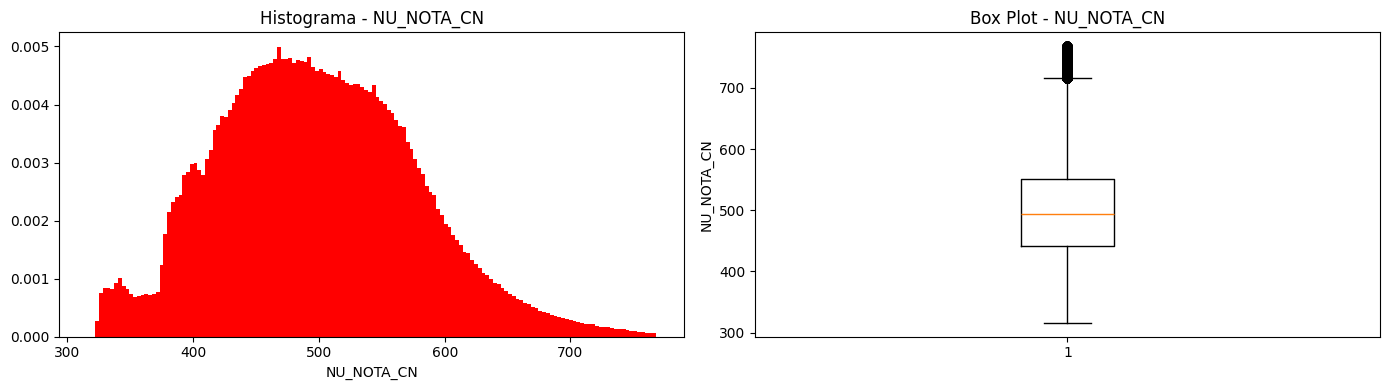

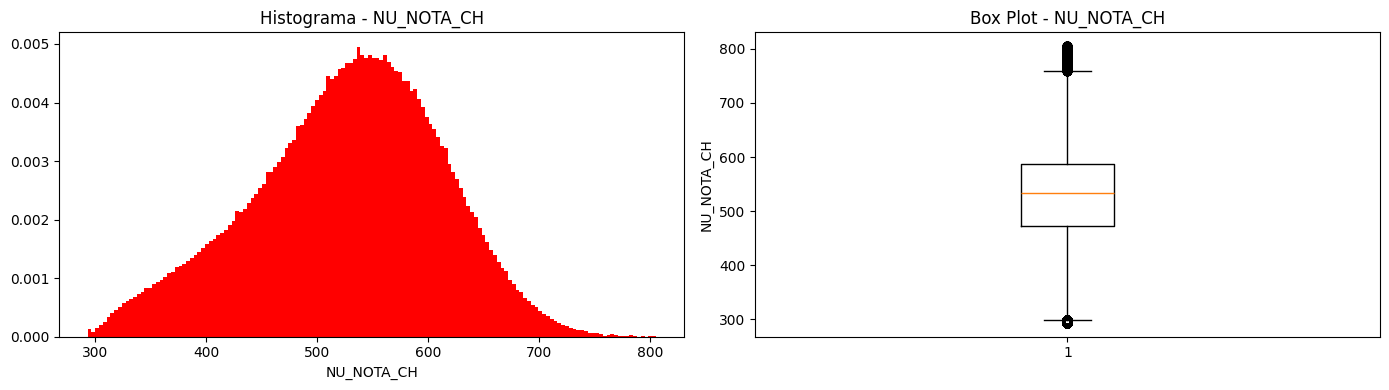

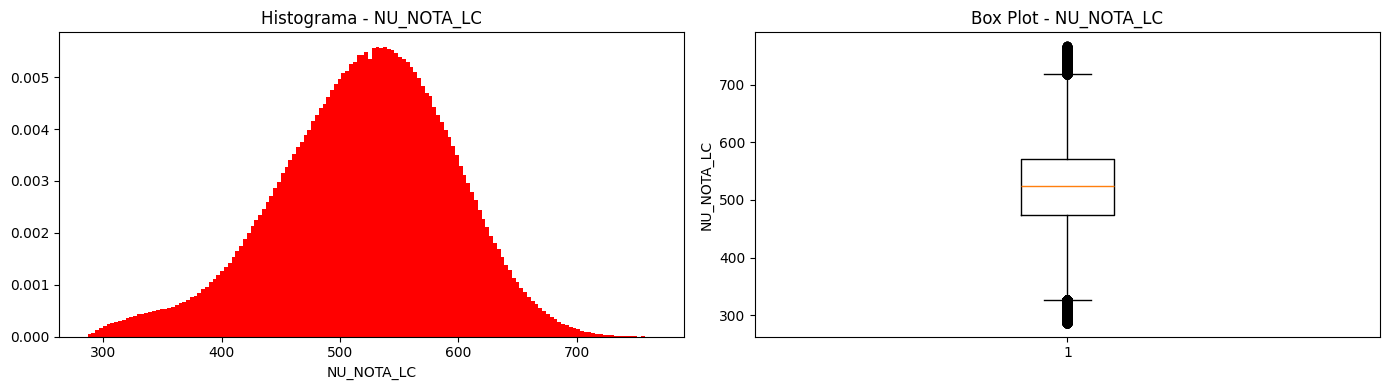

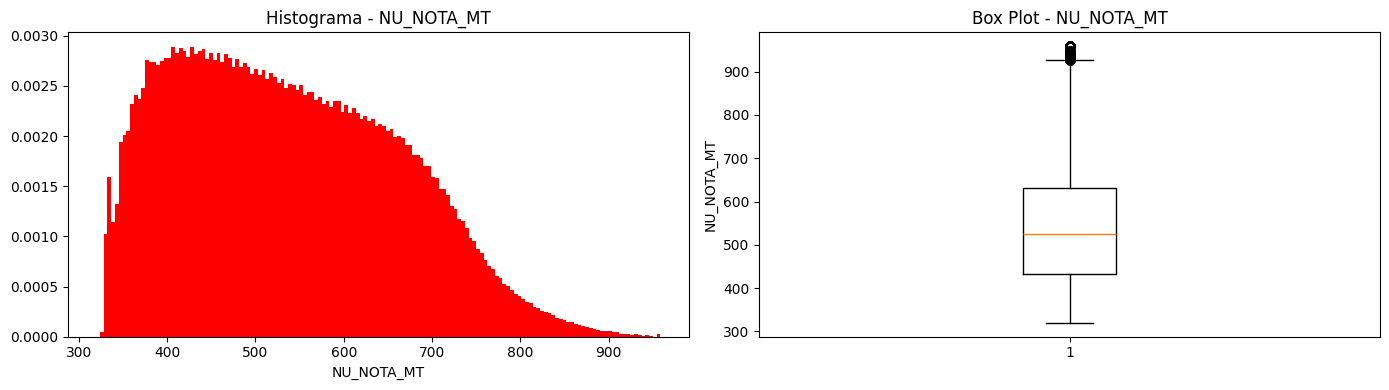

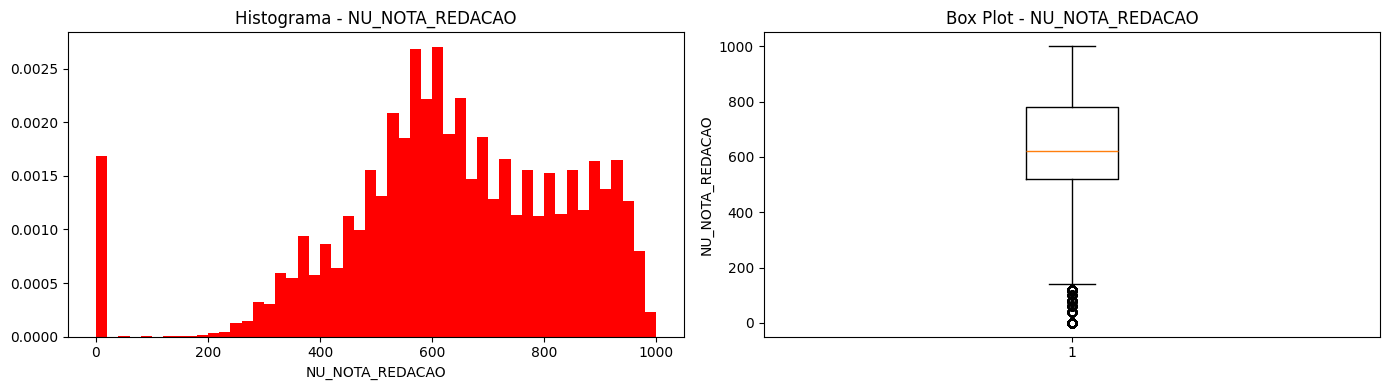

In [31]:
for col in analise_notas:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    if col == 'NU_NOTA_REDACAO':
        ax1.hist(df_resultado[col].dropna(), bins=50, density=True, color='red')
    else:
        ax1.hist(df_resultado[col].dropna(), bins=150, density=True, color='red')
    
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)

    ax2.boxplot(df_resultado[col].dropna(), vert=True)
    ax2.set_title(f'Box Plot - {col}')
    ax2.set_ylabel(col)

    plt.tight_layout()
    plt.show()

In [32]:
df_resultado.head()

,SG_UF_PROVA,MUNICIPIO,COD_MUNICIPIO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
2,RS,Caxias do Sul,4305108,502.0,498.9,475.6,363.2,700.0
3,CE,Fortaleza,2304400,459.0,508.5,507.2,466.7,880.0
4,CE,Quixadá,2311306,402.5,379.2,446.9,338.3,560.0
9,SP,Batatais,3505906,564.7,630.3,610.4,680.2,600.0
10,RN,Natal,2408102,644.9,620.2,626.9,736.3,860.0


In [33]:
df_resultado = df_resultado.groupby('COD_MUNICIPIO').agg(
    UF=('SG_UF_PROVA', 'first'),
    QTD_PARTICIPANTES=('COD_MUNICIPIO', 'size'),
    NOTA_CN_MEDIA=('NU_NOTA_CN', 'mean'),
    NOTA_CH_MEDIA=('NU_NOTA_CH', 'mean'),
    NOTA_LC_MEDIA=('NU_NOTA_LC', 'mean'),
    NOTA_MT_MEDIA=('NU_NOTA_MT', 'mean'),
    NOTA_REDACAO_MEDIA=('NU_NOTA_REDACAO', 'mean')
).reset_index()

df_resultado['NOTA_GERAL_MEDIA'] = df_resultado[['NOTA_CN_MEDIA', 'NOTA_CH_MEDIA', 'NOTA_LC_MEDIA', 'NOTA_MT_MEDIA', 'NOTA_REDACAO_MEDIA']].mean(axis=1)

In [34]:
df_municipio_clustering = df_municipio.merge(
    df_resultado,
    on='COD_MUNICIPIO',
    how='left'
)


df_municipio_clustering.head()

,COD_MUNICIPIO,MUNICIPIO,RENDA_FAMILIAR_SM_MEDIA,UF,QTD_PARTICIPANTES,NOTA_CN_MEDIA,NOTA_CH_MEDIA,NOTA_LC_MEDIA,NOTA_MT_MEDIA,NOTA_REDACAO_MEDIA,NOTA_GERAL_MEDIA
0,1100015,ALTA FLORESTA D'OESTE,1.611017,RO,244,482.932787,507.912705,499.709016,519.652869,654.016393,532.844754
1,1100023,ARIQUEMES,1.776483,RO,1434,487.027685,508.174477,504.455788,511.399930,615.034868,525.218550
2,1100049,CACOAL,1.906845,RO,1571,492.579631,517.086442,509.535582,528.330554,607.218332,530.950108
3,1100056,CEREJEIRAS,1.916968,RO,228,480.655263,505.057895,502.089912,499.915351,617.807018,521.105088
4,1100064,COLORADO DO OESTE,2.139803,RO,269,495.703717,507.392565,500.521561,514.278067,603.420074,524.263197


In [35]:
df_municipio_clustering.isnull().sum()

COD_MUNICIPIO              0
MUNICIPIO                  0
RENDA_FAMILIAR_SM_MEDIA    0
UF                         0
QTD_PARTICIPANTES          0
NOTA_CN_MEDIA              0
NOTA_CH_MEDIA              0
NOTA_LC_MEDIA              0
NOTA_MT_MEDIA              0
NOTA_REDACAO_MEDIA         0
NOTA_GERAL_MEDIA           0
dtype: int64

In [36]:
X_scaled_municipio = df_municipio_clustering.copy()

X_scaled_municipio = X_scaled_municipio.drop(columns=['MUNICIPIO', 'COD_MUNICIPIO', 'RENDA_FAMILIAR_SM_MEDIA', 'UF', 'QTD_PARTICIPANTES', 'NOTA_GERAL_MEDIA'])

col_scatter = ['NOTA_CN_MEDIA', 'NOTA_CH_MEDIA', 'NOTA_LC_MEDIA', 'NOTA_MT_MEDIA', 'NOTA_REDACAO_MEDIA']
scaler = StandardScaler()
X_scaled_municipio[col_scatter] = scaler.fit_transform(X_scaled_municipio[col_scatter])

In [37]:
colunas_notas_media = ['NOTA_CN_MEDIA', 'NOTA_CH_MEDIA', 'NOTA_LC_MEDIA', 'NOTA_MT_MEDIA', 'NOTA_REDACAO_MEDIA', 'NOTA_GERAL_MEDIA']

In [38]:
def media_ponderada(grupo, coluna, peso="QTD_PARTICIPANTES"):
    d = grupo[[coluna, peso]].dropna()
    soma_pesos = d[peso].sum()
    return (d[coluna] * d[peso]).sum() / soma_pesos if soma_pesos != 0 else pd.NA

df_estado_clustering = (
    df_municipio_clustering.groupby("UF")
    .apply(
        lambda g: pd.Series(
            {
                "QTD_PARTICIPANTES": g["QTD_PARTICIPANTES"].sum(),
                "RENDA_FAMILIAR_SM_MEDIA": g["RENDA_FAMILIAR_SM_MEDIA"].mean(),
                **{col: media_ponderada(g, col) for col in colunas_notas_media},
            }
        )
    )
    .reset_index()
    .sort_values("UF")
    .reset_index(drop=True)
)


X_scaled_estado = df_estado_clustering.copy()
X_scaled_estado = X_scaled_estado.drop(columns=['RENDA_FAMILIAR_SM_MEDIA', 'UF', 'QTD_PARTICIPANTES', 'NOTA_GERAL_MEDIA'])
col_scatter = ['NOTA_CN_MEDIA', 'NOTA_CH_MEDIA', 'NOTA_LC_MEDIA', 'NOTA_MT_MEDIA', 'NOTA_REDACAO_MEDIA']
scaler = StandardScaler()
X_scaled_estado[col_scatter] = scaler.fit_transform(X_scaled_estado[col_scatter])

In [39]:
df_municipio_clustering = df_municipio_clustering.sort_values('NOTA_GERAL_MEDIA', ascending=False).reset_index(drop=True)
df_municipio_clustering.head()

,COD_MUNICIPIO,MUNICIPIO,RENDA_FAMILIAR_SM_MEDIA,UF,QTD_PARTICIPANTES,NOTA_CN_MEDIA,NOTA_CH_MEDIA,NOTA_LC_MEDIA,NOTA_MT_MEDIA,NOTA_REDACAO_MEDIA,NOTA_GERAL_MEDIA
0,4322806,VERANÓPOLIS,2.817536,RS,277,535.118773,561.286282,552.026715,606.380866,759.566787,602.875884
1,3133808,ITAÚNA,2.617688,MG,983,541.351577,571.661241,557.431129,622.648220,715.279756,601.674385
2,3556206,VALINHOS,3.288462,SP,1356,553.395206,573.269912,560.341224,627.892330,688.067847,600.593304
3,3556701,VINHEDO,3.078849,SP,783,542.566794,571.063474,559.934227,617.057854,691.187739,596.362018
4,3549904,SÃO JOSÉ DOS CAMPOS,2.658015,SP,8295,540.458047,569.695527,558.558879,618.246655,692.159132,595.823648


In [40]:
X_scaled_municipio.head()

,NOTA_CN_MEDIA,NOTA_CH_MEDIA,NOTA_LC_MEDIA,NOTA_MT_MEDIA,NOTA_REDACAO_MEDIA
0,-0.087440,-0.131951,-0.285804,0.096691,1.058638
1,0.088002,-0.122210,-0.093357,-0.099719,0.246513
2,0.325870,0.209428,0.112591,0.303208,0.083667
3,-0.185018,-0.238187,-0.189276,-0.373037,0.304267
4,0.459718,-0.151307,-0.252861,-0.031223,0.004535


In [41]:
df_estado_clustering['QTD_PARTICIPANTES'] = df_estado_clustering['QTD_PARTICIPANTES'].astype('int64')
df_estado_clustering = df_estado_clustering.sort_values('NOTA_GERAL_MEDIA', ascending=False).reset_index(drop=True)  

df_estado_clustering.head()

,UF,QTD_PARTICIPANTES,RENDA_FAMILIAR_SM_MEDIA,NOTA_CN_MEDIA,NOTA_CH_MEDIA,NOTA_LC_MEDIA,NOTA_MT_MEDIA,NOTA_REDACAO_MEDIA,NOTA_GERAL_MEDIA
0,MG,248051,1.790020,517.057433,546.103199,535.544629,570.257110,663.151449,566.422764
1,SP,406244,2.295522,517.300175,549.233447,542.964210,574.268041,645.452585,565.843692
2,SC,61708,2.628064,517.082646,546.723691,538.015227,569.130913,644.142413,563.018978
3,DF,49654,2.132041,516.976795,546.591457,539.614214,558.148127,640.903049,560.446729
4,RS,109783,2.228614,511.970209,543.324610,538.578467,561.415915,640.879371,559.233715


In [42]:
X_scaled_estado.head()

,NOTA_CN_MEDIA,NOTA_CH_MEDIA,NOTA_LC_MEDIA,NOTA_MT_MEDIA,NOTA_REDACAO_MEDIA
0,-1.157590,-0.743782,-0.560137,-1.134975,-1.009479
1,-0.704247,-0.800192,-0.821223,-0.537087,-0.395338
2,-1.322167,-1.267284,-1.083579,-1.380924,-2.624020
3,-1.142268,-0.920961,-0.987804,-1.490297,-1.394653
4,-0.493961,-0.409424,-0.514355,-0.615930,-0.116989
